正在加载 GPT-OSS ...
正在加载 Qwen-3.5 ...
accuracy 汇总已保存到: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/vivabench_benchmark/accuracy_summary_multi_models.csv
多模型分组条形图已保存到: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/vivabench_benchmark


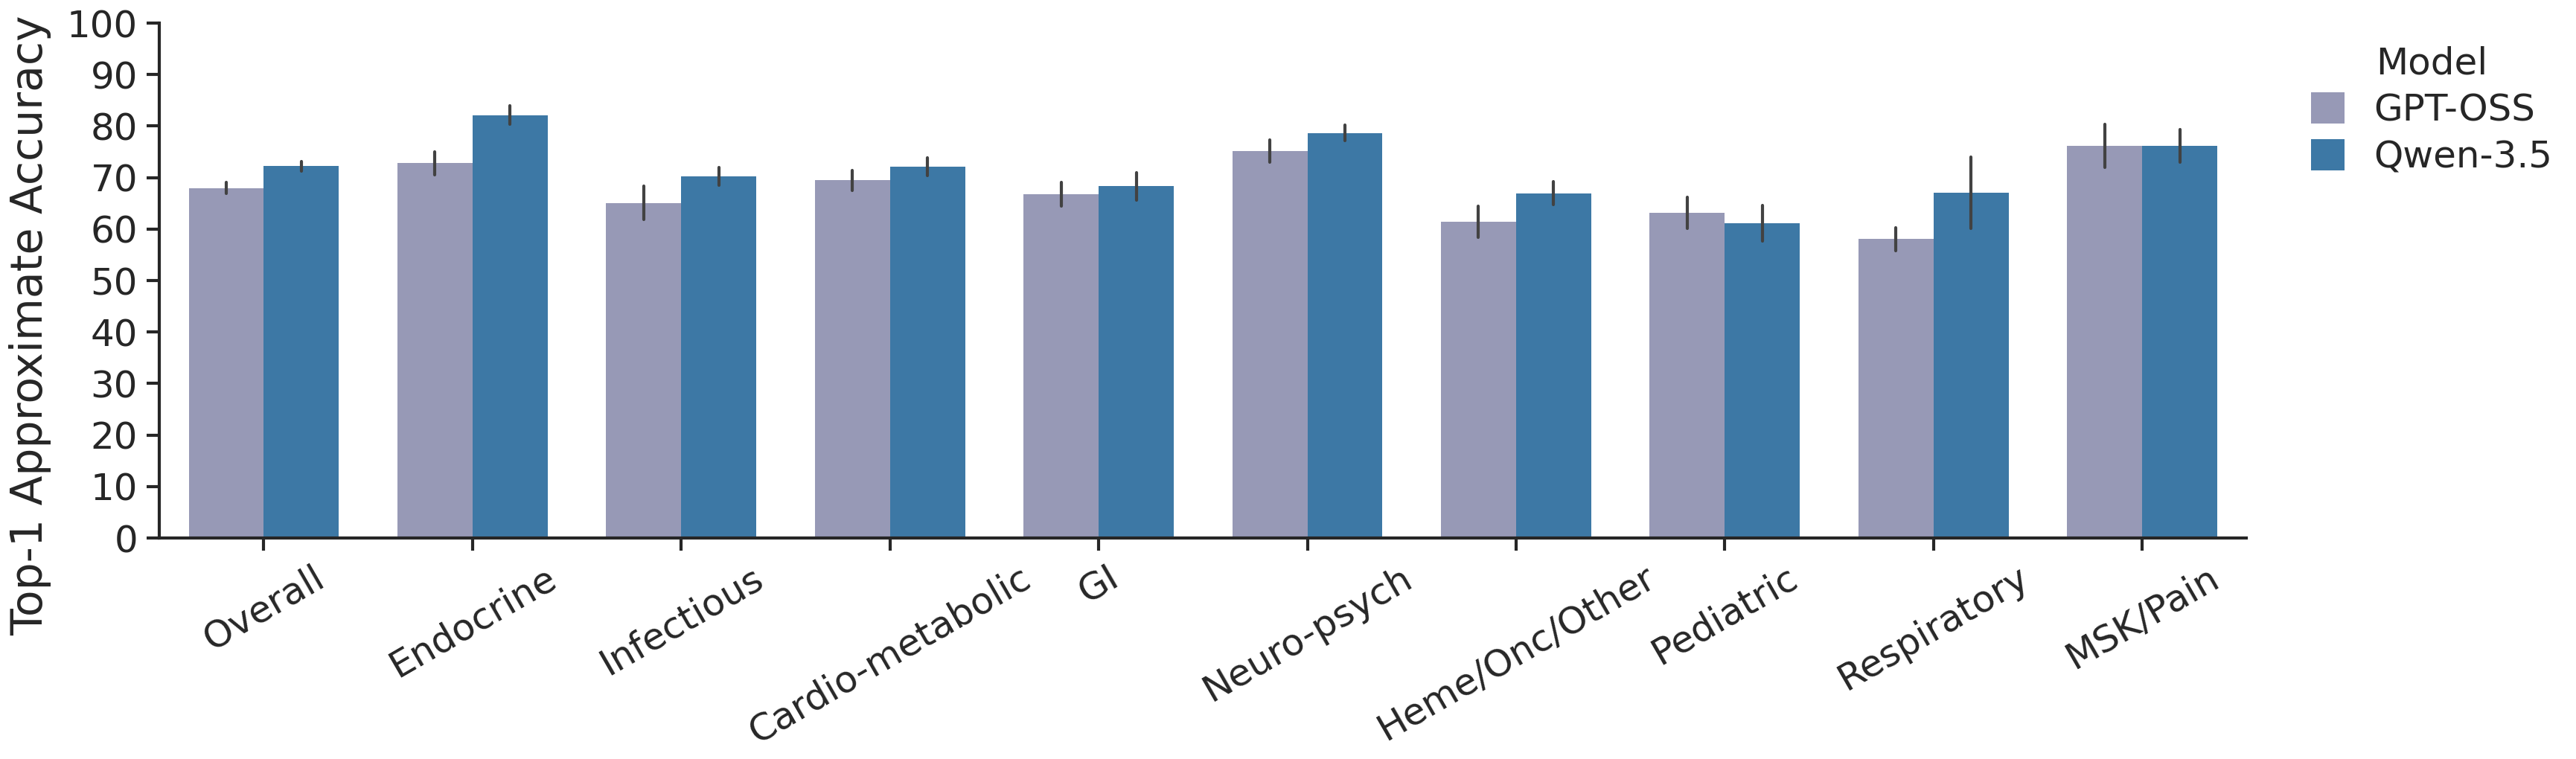

In [ ]:
# vis_comparison_multi_models.py
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import seaborn as sns

# ========== 0) Style ==========
def setup_style(double_column: bool = True):
    if double_column:
        fig_w_in = 7.09
        fig_h_in = 2.2 * 0.85
    else:
        fig_w_in = 3.46 * 0.3
        fig_h_in = 2.0 * 0.7

    sns.set_theme(style="white", context="paper", font_scale=1.0)

    plt.rcParams.update({
        "figure.figsize": (fig_w_in, fig_h_in),
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype":'none',

        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "legend.title_fontsize": 6,

        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.4,
        "ytick.minor.width": 0.4,
        "xtick.major.size": 2.0,
        "ytick.major.size": 2.0,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "axes.linewidth": 0.5,
        "patch.edgecolor": "none",
        "patch.linewidth": 0.0,

        "axes.grid": False,
        "figure.autolayout": False,
        "mathtext.default": "regular",
        "axes.titlepad": 3,
        "axes.labelpad": 2.5,
    })

setup_style(double_column=True)

# ========== 1) Constants and paths ==========
DATASET_NAME_MAP = {
    "vivabench_pubmed": "vivabench_pubmed",
}
ALL_DATASETS = list(DATASET_NAME_MAP.keys())

PLOTS_BASE_DIR = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/vivabench_benchmark"

COHORT_DEMO_PATH = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cohorts/vivabench_case_demographics.csv"
MIN_SPECIALTY_N = 20

SPECIALTY_NAME_MAP = {
    "Endocrine & Reproductive": "Endocrine",
    "Infectious Disease & Immunology": "Infectious",
    "Cardiovascular & Metabolic": "Cardio-metabolic",
    "Gastrointestinal": "GI",
    "Neurological / Psychiatric": "Neuro-psych",
    "Hematology / Oncology / Other": "Heme/Onc/Other",
    "Pediatric": "Pediatric",
    "Respiratory": "Respiratory",
    "Musculoskeletal & Pain": "MSK/Pain",
    "Gynecological / Reproductive": "Gynecologic",
}


df_viva_demo = pd.read_csv(COHORT_DEMO_PATH)
df_viva_demo["uid"] = df_viva_demo["uid"].astype(str)

specialty_counts = df_viva_demo["specialty_group"].value_counts()
specialty_order = specialty_counts[specialty_counts >= MIN_SPECIALTY_N].index.tolist()

case_to_specialty = df_viva_demo.set_index("uid")["specialty_group"].to_dict()

dataset_order = ["Overall"] + specialty_order

MODELS = [
    {
        "label": "GPT-OSS",
        "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/103/103.10",
        "color": "#9294BB", #"#6656A6",
    },
    {
        "label": "Qwen-3.5",
        "dir": "/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/84/84.10",
        "color": "#2c7bb6", #"#74c476", 
    },
]

# ========== 2) Load multiple runs for one model ==========
def _get_run_decision(runs, run_idx):
    if len(runs) <= run_idx:
        return None
    run = runs[run_idx]
    return bool(run.get("effective_decision", run.get("decision", False)))


def load_model_runs(model_label, raw_dir):
    agg_file_path = os.path.join(raw_dir, "vivabench_pubmed_multi_run.jsonl")
    if not os.path.exists(agg_file_path):
        print(f"  警告: 文件 {agg_file_path} 未找到")
        return pd.DataFrame()

    df_agg = pd.read_json(agg_file_path, lines=True)
    if df_agg.empty or "runs" not in df_agg.columns:
        return pd.DataFrame()

    df_agg["case_id"] = df_agg["hadm_id"].astype(str)
    df_agg["specialty_group"] = df_agg["case_id"].map(case_to_specialty)

    missing_specialty = df_agg["specialty_group"].isna().sum()
    if missing_specialty:
        print(f"  警告: {missing_specialty} cases could not be mapped to specialty_group.")

    all_runs_data = []
    num_runs = max(len(runs) for runs in df_agg["runs"])

    for i in range(num_runs):
        run_col = f"run_{i + 1}_decision"
        df_agg[run_col] = df_agg["runs"].apply(lambda runs: _get_run_decision(runs, i))

        # Overall includes all available cases, including n=1 specialty groups.
        overall_accuracy = df_agg[run_col].mean() * 100
        all_runs_data.append({
            "Dataset": "Overall",
            "Accuracy": overall_accuracy,
            "Run": i + 1,
            "Model": model_label,
            "N": int(df_agg[run_col].notna().sum()),
        })

        # Subgroup bars only include specialty groups with n >= MIN_SPECIALTY_N.
        for specialty in specialty_order:
            sub = df_agg[df_agg["specialty_group"] == specialty]
            if sub.empty:
                continue

            all_runs_data.append({
                "Dataset": specialty,
                "Accuracy": sub[run_col].mean() * 100,
                "Run": i + 1,
                "Model": model_label,
                "N": int(sub[run_col].notna().sum()),
            })

    return pd.DataFrame(all_runs_data)


# ========== 3) Aggregate multiple models ==========
all_model_dfs = []

for model_cfg in MODELS:
    print(f"正在加载 {model_cfg['label']} ...")
    df_model = load_model_runs(model_cfg["label"], model_cfg["dir"])
    if not df_model.empty:
        all_model_dfs.append(df_model)

if not all_model_dfs:
    raise ValueError("没有成功加载任何 model 的结果，请检查路径。")

df_combined = pd.concat(all_model_dfs, ignore_index=True)

# dataset_order = ["Overall"] #+ [name for name in DATASET_NAME_MAP.values()]
df_combined["Dataset"] = df_combined["Dataset"].astype(str).str.strip()
df_combined["Dataset"] = pd.Categorical(
    df_combined["Dataset"],
    categories=dataset_order,
    ordered=True
)
df_combined = df_combined.sort_values("Dataset")

model_order = [m["label"] for m in MODELS]

df_combined["Model"] = pd.Categorical(
    df_combined["Model"],
    categories=model_order,
    ordered=True
)

df_combined["DatasetLabel"] = (
    df_combined["Dataset"]
    .astype(str)
    .replace(SPECIALTY_NAME_MAP)
)
dataset_label_order = [
    "Overall" if x == "Overall" else SPECIALTY_NAME_MAP.get(x, x)
    for x in dataset_order
]
df_combined["DatasetLabel"] = pd.Categorical(
    df_combined["DatasetLabel"],
    categories=dataset_label_order,
    ordered=True,
)



# ========== Additional export: accuracy for each model (% +/- SD) ==========
df_summary = (
    df_combined
    .groupby(["Dataset", "Model"], observed=True)["Accuracy"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "Accuracy_mean", "std": "Accuracy_sd"})
)

# Keep two decimal places
df_summary["Accuracy_mean"] = df_summary["Accuracy_mean"].round(2)
df_summary["Accuracy_sd"] = df_summary["Accuracy_sd"].round(2)

# Create display columns: xx.xx +/- yy.yy
df_summary["Accuracy (% ± SD)"] = (
    df_summary["Accuracy_mean"].map(lambda x: f"{x:.2f}")
    + " ± "
    + df_summary["Accuracy_sd"].fillna(0).map(lambda x: f"{x:.2f}")
)

summary_csv_path = os.path.join(PLOTS_BASE_DIR, "accuracy_summary_multi_models.csv")
df_summary.to_csv(summary_csv_path, index=False)

print(f"accuracy 汇总已保存到: {summary_csv_path}")


# ========== 4) Plot ==========
fig, ax = plt.subplots()

color_palette = {m["label"]: m["color"] for m in MODELS}

ax = sns.barplot(
    data=df_combined,
    x="DatasetLabel",
    y="Accuracy",
    hue="Model",
    hue_order=model_order,
    palette=color_palette,
    errorbar="sd",
    capsize=0,
    err_kws={"linewidth": 0.5},
    width=0.72,
    linewidth=0,
    edgecolor="none",
    ax=ax,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.5)

ax.tick_params(
    axis="both",
    which="major",
    width=0.5,
    length=2.0,
    direction="out",
    top=False,
    right=False,
    bottom=True,
    left=True,
    pad=1.5,
)

ax.set_xlabel("")
ax.set_ylabel("Top-1 Approximate Accuracy (%)")

ymin = max(0, df_combined["Accuracy"].min() - 5)
ax.set_ylim(0, 100.0)
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

ax.tick_params(axis="x", labelrotation=30)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    title="Model",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    frameon=False,
    handlelength=0.9,
    handleheight=0.9,
    borderaxespad=0.2,
    labelspacing=0.3,
    columnspacing=0.8,
)

plt.tight_layout(rect=[0, 0, 0.84, 1])

# ========== 5) Save ==========
os.makedirs(PLOTS_BASE_DIR, exist_ok=True)
out_svg = os.path.join(PLOTS_BASE_DIR, "accuracy_comparison_multi_models.svg")
out_png = os.path.join(PLOTS_BASE_DIR, "accuracy_comparison_multi_models.png")
out_pdf = os.path.join(PLOTS_BASE_DIR, "accuracy_comparison_multi_models.pdf")

plt.savefig(out_svg, format="svg", bbox_inches=None)
plt.savefig(out_png, format="png", bbox_inches=None)
plt.savefig(out_pdf, format="pdf", bbox_inches=None)

print(f"多模型分组条形图已保存到: {PLOTS_BASE_DIR}")
plt.show()
plt.close()
